In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
B_MODEL = "JF12"        # options: "simple" or "JF12"

# ==========================
# Physical parameters
# ==========================
kpc = 3.086e21 # to cm
c   = 3e10 #to cm

R_max = 20 * kpc
z_max = 5 * kpc

# Simple model parameters
B0 = 5.0 #muG
rB = 10 * kpc
zB = 2 * kpc
B_IC = 3.2

pitch_angle = np.deg2rad(-12.0)
z0 = 0.5 * kpc

# Simulation
dt = 5e9
N_steps = 5000
print('Simulation time:', dt*5000/3.154e+7 / 1e3, 'kyr')
N_particles = int(1e3)

# Momentum evolution
b0 = 0
a0 = 0.6   # GeV / (s * microGauss)  --- This must be the Bohr magnetic chage, that goes multiplied by the magnetic field (F = q_b * B)
alpha0 = a0

Simulation time: 792.6442612555485 kyr


In [3]:
# Gas model
def nH2_NS_av(Rr, Zz):
    return 0.94*(11.2*np.exp(-(Rr**2)/.874) + 0.83*np.exp(-((Rr-4)/3.2)**2.) )*np.exp(-np.log(2)*(Zz/(1.06/1000.*(10.8*np.exp(0.28*(Rr))+42.78)))**2.)

In [4]:

def B_field_vector(r, phi, z, add_random=True, f_random=1.0, sigma_frac=1):
    """
    Return total B-field at a point, optionally with Gaussian random component.
    f_random: average B_random / B_regular
    sigma_frac: relative width of Gaussian
    """
    # Regular field
    if B_MODEL == "simple":
        Br, Bphi, Bz = simple_B_field(r, phi, z)
    elif B_MODEL == "JF12":
        Br, Bphi, Bz = JF12_B_field(r, phi, z)

    B_reg = np.sqrt(Br**2 + Bphi**2 + Bz**2)

    if add_random and B_reg > 0:
        # Random unit vector
        rand_dir = np.random.randn(3)
        rand_dir /= np.linalg.norm(rand_dir)       

        # Gaussian magnitude
        rand_mag = np.random.normal(loc=f_random*B_reg, scale=sigma_frac*f_random*B_reg)
        rand_mag = max(rand_mag, 0.0)  # prevent negative B
        # Random intensity ~ same as regular field
        #f_random = 1.0  # B_random / B_regular on average
        #rand_mag = B_reg * f_random * np.random.uniform(0.5, 1.5)
        #rand_mag = B_reg * np.random.uniform(0.5, 1.5)  # ~B_reg with some scatter


        # Add to regular field
        Br += rand_dir[0] * rand_mag
        Bphi += rand_dir[1] * rand_mag
        Bz += rand_dir[2] * rand_mag

    return Br, Bphi, Bz


        
def simple_B_field(r, phi, z):

    Bmag = B0 * np.exp(-r/rB) * np.exp(-np.abs(z)/zB)

    Br_disk   = np.sin(pitch_angle)
    Bphi_disk = np.cos(pitch_angle)

    Bz_halo = 0.1 * np.tanh(z/z0)

    dBr = Br_disk
    dBphi = Bphi_disk
    dBz = Bz_halo

    norm = np.sqrt(dBr**2 + dBphi**2 + dBz**2)

    dBr /= norm
    dBphi /= norm
    dBz /= norm

    return Bmag*dBr, Bmag*dBphi, Bmag*dBz


def JF12_B_field(r, phi, z):
    """
    Regular Galactic Magnetic Field from Jansson & Farrar (2012)

    Parameters
    ----------
    r : float
        Galactocentric radius [kpc]
    phi : float
        Azimuth angle [rad]
    z : float
        Height above Galactic plane [kpc]

    Returns
    -------
    Br, Bphi, Bz : float
        Cylindrical magnetic field components [microGauss]
    """

    # ---------------------------
    # Parameters (JF12 best fit)
    # ---------------------------

    # Disk spiral arms (μG)
    b = np.array([0.1, 3.0, -0.9, -0.8, -2.0, -4.2, 0.0, 2.7])

    r_arms = np.array([5.1, 6.3, 7.1, 8.3, 9.8, 11.4, 12.7, 15.5])

    pitch = np.deg2rad(11.5)

    # Halo
    Bn = 1.4
    Bs = -1.1
    r_n = 9.22*kpc
    r_s = 16.7*kpc
    w_h = 0.2*kpc
    z0 = 5.3*kpc

    # X-field
    Bx = 4.6
    theta0 = np.deg2rad(49.)
    rc = 4.8*kpc
    rX = 2.9*kpc

    # Disk height transition
    h_disk = 0.4*kpc
    w_disk = 0.27*kpc

    # ---------------------------
    # Helper functions
    # ---------------------------

    def logistic(x, x0, w):
        return 1. / (1. + np.exp(-(x - x0) / w))

    # ---------------------------
    # Disk field
    # ---------------------------

    Br_disk = 0.
    Bphi_disk = 0.
    Bz_disk = 0.

    if 5. <= r <= 20.:

        z_factor = 1 - logistic(abs(z), h_disk, w_disk)

        phi_arm = phi - np.log(r / r_arms) / np.tan(pitch)

        arm_index = np.argmin(np.abs(phi_arm))

        B0 = b[arm_index] * z_factor

        Br_disk = B0 * np.sin(pitch)
        Bphi_disk = B0 * np.cos(pitch)

    # ---------------------------
    # Toroidal halo
    # ---------------------------

    Br_halo = 0.
    Bz_halo = 0.

    if z >= 0:
        B0 = Bn * (1 - logistic(r, r_n, w_h))
    else:
        B0 = Bs * (1 - logistic(r, r_s, w_h))

    Bphi_halo = B0 * np.exp(-abs(z) / z0)

    # ---------------------------
    # X-shaped poloidal field
    # ---------------------------

    R = np.sqrt(r**2 + z**2)

    if R == 0:
        Br_X = 0.
        Bz_X = 0.
    else:

        theta = np.arctan2(abs(z), r)

        if r < rc:
            theta_p = theta0 * r / rc
        else:
            theta_p = theta0

        B0 = Bx * np.exp(-R / rX)

        Br_X = B0 * np.cos(theta_p) * np.sign(z)
        Bz_X = B0 * np.sin(theta_p)

    Bphi_X = 0.

    # ---------------------------
    # Total field
    # ---------------------------

    Br = Br_disk + Br_halo + Br_X
    Bphi = Bphi_disk + Bphi_halo + Bphi_X
    Bz = Bz_disk + Bz_halo + Bz_X

    return Br, Bphi, Bz

In [8]:

def inject_particle(momentum = 1e5): ## Uniform injection
    Area_side = 4 * np.pi * R_max * z_max
    Area_caps = 2 * np.pi * R_max**2
    Area_total = Area_side + Area_caps

    MyProb = Area_side / Area_total

    if np.random.rand() < MyProb:
        # Side surface
        r = R_max
        z = np.random.uniform(-z_max, z_max)
    else:
        # Caps
        r = R_max * np.sqrt(np.random.rand())
        z = z_max if np.random.rand() < 0.5 else -z_max
    
    phi = np.random.uniform(0, 2*np.pi)

    p = momentum #1e5 #GeV/c 
    return r, phi, z, p

    

def dp_dt(p, Bmag):
    loss = -b0 * p**2 * (Bmag**2 + B_IC**2)
    gain = a0 * Bmag

    return loss + gain

In [9]:
# --- Initialize storage ---
z_plane = 0.1 * kpc # Just to define where the Galactic plane is

# Storing some quantities useful to plot
residence_times = []
path_lengths = []
grammages = []

arrival_rs = []
arrival_angles = []

crossings_counts = []

trajectories = []
angle_changes = []


My_p = 1e5 # GeV/c
for n in range(N_particles):
    n_crossings = 0
    
    r, phi, z, p = inject_particle(momentum = My_p)
    traj = []

    # --- Random momentum components ---
    if z == z_max:
        # Injected from top cap, must move downward       
        cos_theta = np.random.uniform(-1, 1)
        sin_theta = np.sqrt(1 - cos_theta**2)
        phi_mom = np.random.uniform(0, 2*np.pi)

        pr   = My_p * sin_theta * np.cos(phi_mom)  
        pphi = My_p * sin_theta * np.sin(phi_mom)
        pz   = -np.abs(My_p * cos_theta) # pz going down always

    elif z == -z_max:
        # Injected from bottom cap, must move upward
        cos_theta = np.random.uniform(-1, 1)
        sin_theta = np.sqrt(1 - cos_theta**2)
        phi_mom = np.random.uniform(0, 2*np.pi)

        pr   = My_p * sin_theta * np.cos(phi_mom)  # inward
        pphi = My_p * sin_theta * np.sin(phi_mom)
        pz   = np.abs(My_p * cos_theta)  # pz going up always
    
    elif r == R_max:
        # Injected from side, must move inward radially
        cos_theta = np.random.uniform(-1, 1)  # allows upward or downward motion
        sin_theta = np.sqrt(1 - cos_theta**2)
        phi_mom = np.random.uniform(0, 2*np.pi)
        
        # Cylindrical components
        pr   =  -np.abs(My_p * sin_theta * np.cos(phi_mom))  # inward toward center
        pphi =  My_p * sin_theta * np.sin(phi_mom)
        pz   =  My_p * cos_theta
    
    t_residence = 0.0
    l_path = 0.0
    X_grammage = 0.0

    crossed_plane = False

    for i in range(N_steps):

        # Momentum magnitude
        p_vec = np.array([pr, pphi, pz])
        p_mag = np.linalg.norm(p_vec)

        if p_mag <= 0:
            break

        # Magnetic field
        Br, Bphi, Bz = B_field_vector(r, phi, z, add_random=True, f_random=1.0, sigma_frac=1)
        #Br, Bphi, Bz = B_field_vector(r, phi, z, add_random=False)
        Bmag = np.sqrt(Br**2 + Bphi**2 + Bz**2)

        # Acceleration along field
        if Bmag > 0:           
            b_hat = np.array([Br, Bphi, Bz]) / Bmag
            dp_vec = dp_dt(p_mag, Bmag) *dt * b_hat #alpha0 * Bmag * b_hat * dt
            p_vec += dp_vec
            pr, pphi, pz = p_vec

        # Scalar losses/gains
        p_mag_new = np.linalg.norm(p_vec)
        dp_scalar = dp_dt(p_mag_new, Bmag) * dt
        scale = max((p_mag_new + dp_scalar) / p_mag_new, 0)

        pr *= scale
        pphi *= scale
        pz *= scale

        p_vec = np.array([pr, pphi, pz])
        p_mag_new = np.linalg.norm(p_vec)

        # Velocity
        vr   = c * pr / p_mag_new
        vphi = 0 if r == 0 else c * pphi / (p_mag_new * r)
        vz   = c * pz / p_mag_new
    
        # Update position
        r_new = r + vr*dt
        phi_new = phi + vphi*dt
        z_new = z + vz*dt

        
        # --- Galactic plane band crossing (|z| < 100 pc) ---
        in_plane_now = abs(z) <= z_plane
        in_plane_new = abs(z_new) <= z_plane

        # Count entry into the plane region
        if not in_plane_now and in_plane_new:
            n_crossings += 1
            
        # --- Boundary check BEFORE accumulating ---
        if r_new < 0 or r_new > R_max or abs(z_new) > z_max:
            break

        # --- Step distance ---
        dx = r_new*np.cos(phi_new) - r*np.cos(phi)
        dy = r_new*np.sin(phi_new) - r*np.sin(phi)
        dz = z_new - z
        dr = np.sqrt(dx**2 + dy**2 + dz**2)

        # --- Accumulate quantities ---
        l_path += dr
        t_residence += dt

        density = 2 * nH2_NS_av(r/kpc, z/kpc)
        X_grammage += density * dr

        # --- Galactic plane crossing ---
        if not crossed_plane and z * z_new <= 0:
            crossed_plane = True
            arrival_rs.append(r_new)

            p_hat = p_vec / np.linalg.norm(p_vec)
            angle_to_plane = np.arccos(np.clip(abs(p_hat[2]), 0, 1))
            arrival_angles.append(np.rad2deg(angle_to_plane))

        # Update state
        r, phi, z = r_new, phi_new, z_new
        traj.append((r/kpc, z/kpc, p_mag_new))

    # Save results
    crossings_counts.append(n_crossings)
    trajectories.append(np.array(traj))
    residence_times.append(t_residence)
    path_lengths.append(l_path)
    grammages.append(X_grammage)

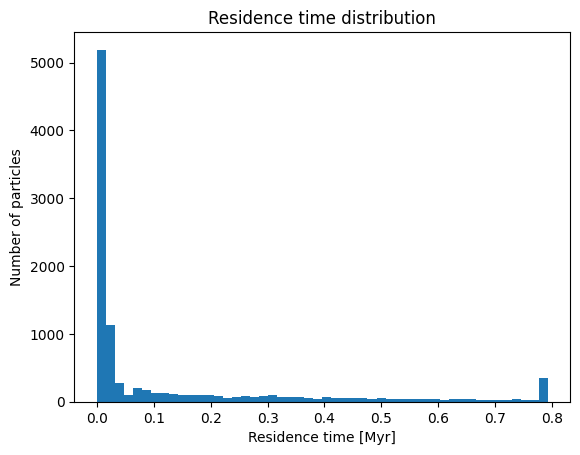

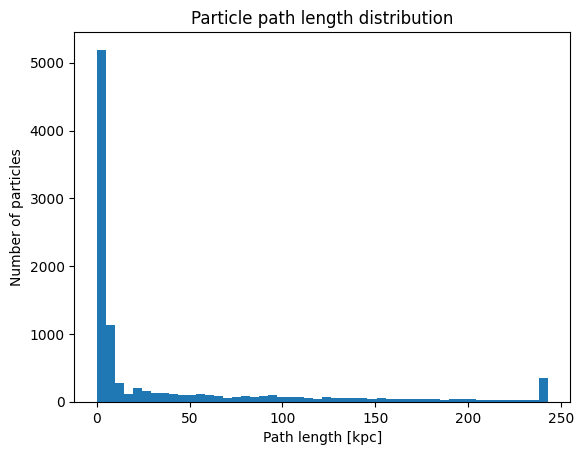

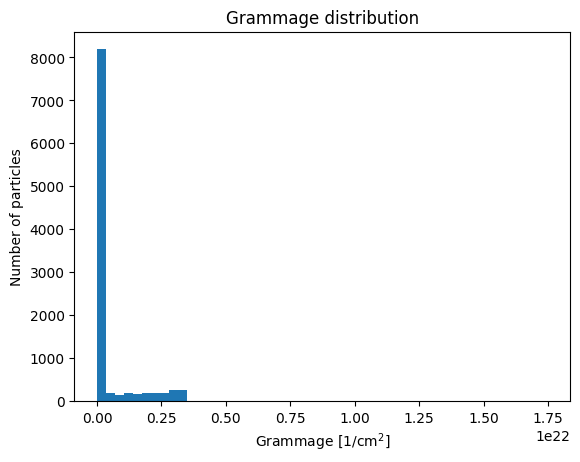

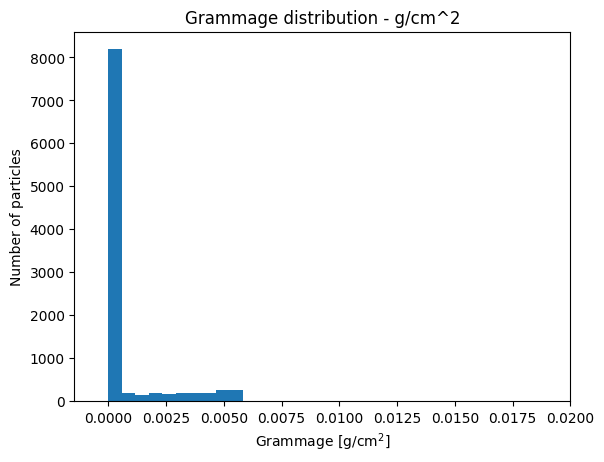

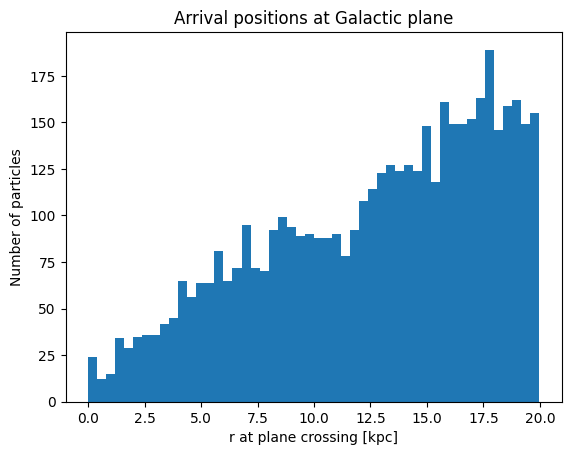

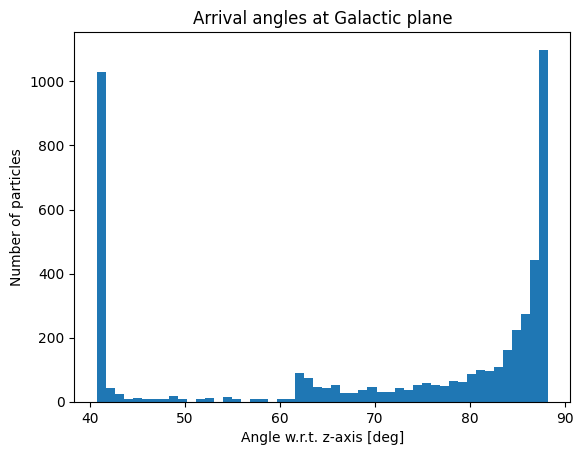


Fraction with residence time > threshold:
> 0.01 Myr: 0.490
> 0.05 Myr: 0.338
> 0.1 Myr: 0.288
> 0.2 Myr: 0.219
> 0.5 Myr: 0.096

Fraction with path length > threshold:
> 1 kpc: 0.498
> 2 kpc: 0.495
> 5 kpc: 0.480
> 7.5 kpc: 0.426
> 10 kpc: 0.365
> 20 kpc: 0.325

Fraction with arrival angle < threshold:
< 5 deg: 0.000
< 10 deg: 0.000
< 20 deg: 0.000
< 60 deg: 0.258

Average grammage traversed:
Mean grammage: 0.0007189219071339948 g/cm^2


In [98]:
# --- Convert units ---
res_times_myr = np.array(residence_times) / 3.154e+7 / 1e6
path_lengths_kpc = np.array(path_lengths) / kpc
arrival_rs_kpc = np.array(arrival_rs) / kpc
arrival_angles_arr = np.array(arrival_angles)
grammages_arr = np.array(grammages)

# --- Residence times ---
plt.figure()
plt.hist(res_times_myr, bins=50)
plt.xlabel("Residence time [Myr]")
plt.ylabel("Number of particles")
plt.title("Residence time distribution")
plt.savefig('Residence_time{}GeV_NoRandom.png'.format(My_p))
plt.show()

# --- Path lengths ---
plt.figure()
plt.hist(path_lengths_kpc, bins=50)
plt.xlabel("Path length [kpc]")
plt.ylabel("Number of particles")
plt.title("Particle path length distribution")
plt.savefig('Path_length_{}GeV_NoRandom.png'.format(My_p))
plt.show()

# --- Grammage ---
plt.figure()
plt.hist(grammages_arr, bins=50)
plt.xlabel(r"Grammage [1/cm$^2$]")
plt.ylabel("Number of particles")
plt.title("Grammage distribution")
plt.savefig('Grammage_{}GeV_NoRandom.png'.format(My_p))
plt.show()

plt.figure()
plt.hist(grammages_arr*1.67e-24, bins=50)
plt.xlabel(r"Grammage [g/cm$^2$]")
plt.ylabel("Number of particles")
plt.title("Grammage distribution - g/cm^2")
plt.xlim(right=0.02)
plt.savefig('Grammage2_{}GeV_NoRandom.png'.format(My_p))
plt.show()

# --- Arrival positions ---
plt.figure()
plt.hist(arrival_rs_kpc, bins=50)
plt.xlabel("r at plane crossing [kpc]")
plt.ylabel("Number of particles")
plt.title("Arrival positions at Galactic plane")
plt.savefig('Arrival_position_{}GeV_NoRandom.png'.format(My_p))
plt.show()

# --- Arrival angles ---
plt.figure()
plt.hist(arrival_angles_arr, bins=50)
plt.xlabel("Angle w.r.t. z-axis [deg]")
plt.ylabel("Number of particles")
plt.title("Arrival angles at Galactic plane")
plt.savefig('Arrival_angles_{}GeV_NoRandom.png'.format(My_p))
plt.show()

# =========================
# 📈 FRACTIONS
# =========================

# --- Residence time thresholds ---
thresholds_time = [0.01, 0.05, 0.1, 0.2, 0.5]

print("\nFraction with residence time > threshold:")
for t in thresholds_time:
    frac = np.mean(res_times_myr > t)
    print(f"> {t} Myr: {frac:.3f}")

# --- Path length thresholds ---
thresholds_path = [1, 2, 5, 7.5, 10, 20]

print("\nFraction with path length > threshold:")
for L in thresholds_path:
    frac = np.mean(path_lengths_kpc > L)
    print(f"> {L} kpc: {frac:.3f}")

# --- Angle thresholds ---
thresholds_angle = [5, 10, 20, 60]

print("\nFraction with arrival angle < threshold:")
for ang in thresholds_angle:
    frac = np.mean(arrival_angles_arr < ang)
    print(f"< {ang} deg: {frac:.3f}")

print("\nAverage grammage traversed:")
print('Mean grammage:', np.mean(grammages_arr*1.67e-24), 'g/cm^2')
values, counts = np.unique(grammages_arr*1.67e-24, return_counts=True)
mode_value = values[np.argmax(counts)]
#print('Most common grammage:', mode_value, 'g/cm^2')

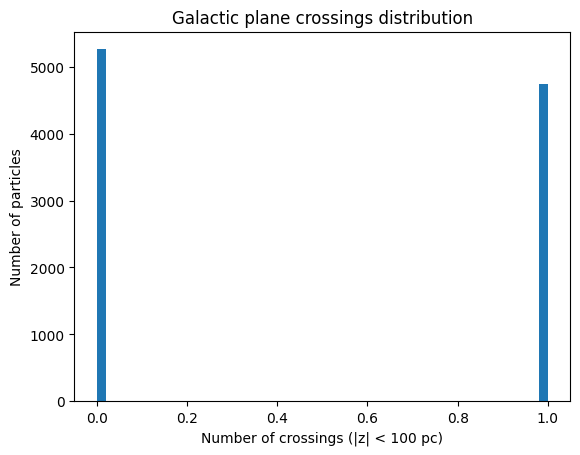


Crossing statistics:
Average crossings per particle: 0.474
Average crossings (given ≥1 crossing): 1.000
Fraction of particles that ever cross the plane: 0.474


In [99]:
crossings_arr = np.array(crossings_counts)

plt.figure()
plt.hist(crossings_arr, bins=50)
plt.xlabel("Number of crossings (|z| < 100 pc)")
plt.ylabel("Number of particles")
plt.title("Galactic plane crossings distribution")
plt.savefig('Crossings_{}GeV_NoRandom.png'.format(My_p))
plt.show()


# --- Average crossings (all particles) ---
avg_crossings = np.mean(crossings_arr)

# --- Only particles that crossed at least once ---
mask_crossed = crossings_arr > 0
avg_crossings_cond = np.mean(crossings_arr[mask_crossed]) if np.any(mask_crossed) else 0

print("\nCrossing statistics:")
print(f"Average crossings per particle: {avg_crossings:.3f}")
print(f"Average crossings (given ≥1 crossing): {avg_crossings_cond:.3f}")
print(f"Fraction of particles that ever cross the plane: {np.mean(mask_crossed):.3f}")

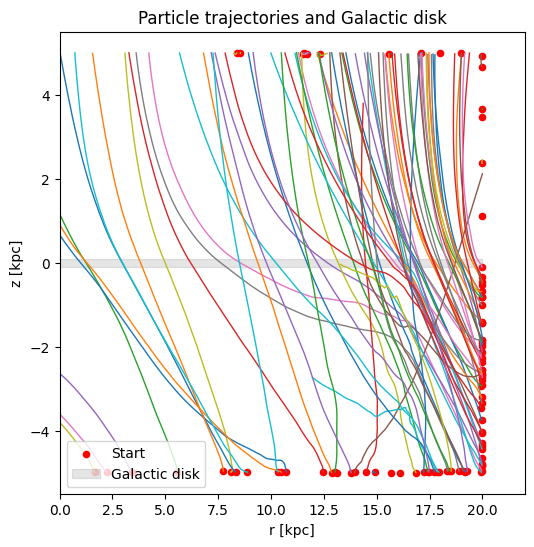

In [10]:
z_disk = z_plane #0.1*kpc

plt.figure(figsize=(6,6))

for traj in trajectories[:200]:
    if not len(traj):
        continue
    # Plot trajectory
    plt.plot(traj[:,0], traj[:,1], lw=1)

    # Mark initial position
    plt.scatter(traj[0,0], traj[0,1], color='red', s=20, marker='o', label='Start')

plt.fill_between([0, R_max/kpc],
                 -z_disk/kpc, z_disk/kpc,
                 color='gray', alpha=0.2,
                 label='Galactic disk')

plt.xlabel("r [kpc]")
plt.ylabel("z [kpc]")
plt.xlim(0, 22)

# Avoid repeating 'Start' in legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title("Particle trajectories and Galactic disk")
plt.savefig('ParticleTracks_{}GeV.png'.format(My_p))
plt.show()

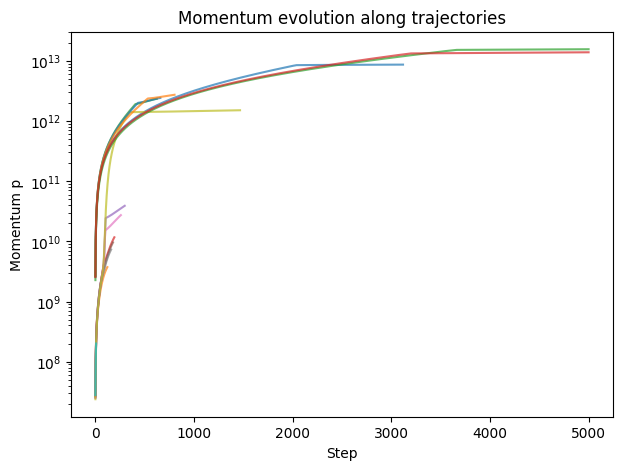

In [101]:
plt.figure(figsize=(7,5))
for traj in trajectories[:25]:
    if not len(traj):
        continue
    plt.plot(traj[:,2], alpha=0.7)

plt.xlabel("Step")
plt.ylabel("Momentum p")
plt.yscale("log")
plt.title("Momentum evolution along trajectories")
plt.savefig('MomentumEvolution_{}GeV.png'.format(My_p))
plt.show()
